# Ley de Gauss $ \vec{∇} \cdot \vec{E}=\frac{ρ}{ϵ_{0}}$
---
Dada una carga puntual $q$ podemos calcular el campo que está genera en una posición  $\vec{r}$ esta dado por:

\begin{align}
 \vec{E}(r)= \frac{1}{4 π ϵ_{0}}\frac{q}{r^{2}}\hat{r}=\frac{q}{4 π ϵ_{0}r^{3}}r
\end{align}

La ley de gauss postula que dado un campo $\vec{E}$ su divergencia es igual a la carga $\rho$ entre la permitividad eléctrica en el vacío $ϵ_{0}$. Esto significa, que la fuente del campo eléctrico son las cargas, dicho de otro modo, el compo eléctrico $\vec{E}$ es origindado por las cargas como fuentes.

Para solucionar numéricamente la ley de gauss usaremos python y las librerias ***numpy*** que se usa para operear con arreglos matriciales y para generar las gráficas vamos a usar la librería ***matplotlib***.  

Usaremos ***numpy*** para generar un arreglo matricial que discretice el espacio, dado que el cálculo del continuo no es posible, se cálculan multiples puntos en una red,la cantidad de puntos en una red es llamada resolución y a mayor cantidad de puntos por unidad de area tendremos mayor resolución pero también mayor costo computacional.


Cómo ejemplo vamos a solucionar el dipolo eléctrico, este sistemá consiste en dos cargas de signo apuesto separadas por una corta distancia

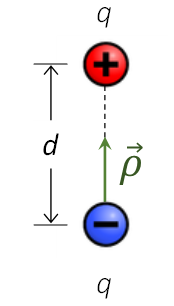










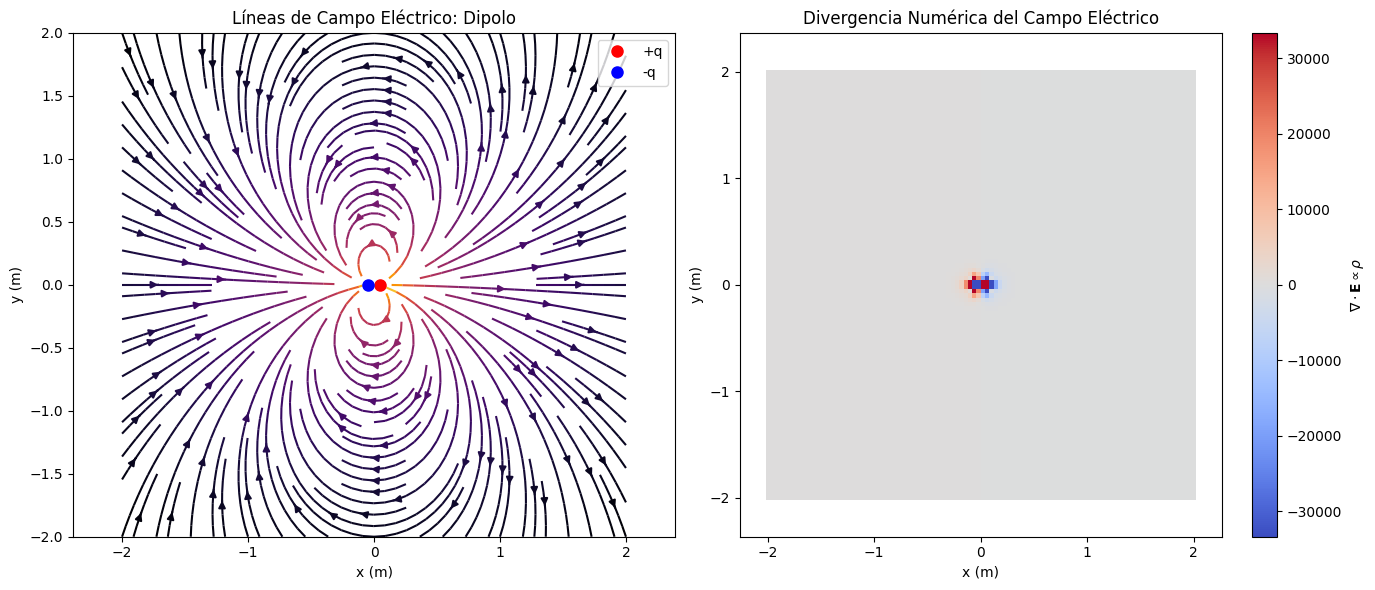

In [4]:
import numpy as np
import matplotlib.pyplot as plt

#=========================================================================#
# Las constantes que usaremos son la permitividad dieléctrica en el vació #
# epsilon_0 y la constante de coulomb k.                                  #
#=========================================================================#

Eps_0= 8.8541878128e-12 # Permitividad del vacío (C^2/N*m^2)
k= 1/(4*np.pi*Eps_0) # Constante de coulomb (N*m^2/C^2)

#=======================================================================#
# Vamos a definir una función que use los rangos deseados para los ejes #
# "x" y "y" y la resolución deseada en sus argumentos, en este caso     #
# la malla será 2D, osea, veremos el dipolo en plano xy, aquí usaremos  #
# la función linspace de numpy para crearla.                            #
#=======================================================================#

def malla(rango_x,rango_y,resolucion):
  x=np.linspace(-rango_x,rango_x,resolucion)
  y=np.linspace(-rango_y,rango_y,resolucion)
  X,Y=np.meshgrid(x,y)
  return X,Y,x,y


# Ahora vamos a definir el campo generado por carga puntual

def campo(q, pos_q,X,Y):
  rx=X-pos_q[0]
  ry=Y-pos_q[1]

  r=np.sqrt(rx**2+ry**2)

  r[r<1e-10]=np.inf # Manejo de la singularidad: evitamos división por cero en el centro de la carga

  Ex=k*q/r**3*rx
  Ey=k*q/r**3*ry

  return Ex,Ey


#Calculamos la divergencia numérica de un campo vectorial 2D usando diferencias finitas.


def divergencia(Fx,Fy, dx,dy):
  dFx_dx = np.gradient(Fx, dx, axis=1) # np.gradient devuelve la derivada respecto a los ejes del arreglo.

  dFy_dy = np.gradient(Fy, dy, axis=0) # El eje 0 corresponde a Y (filas), el eje 1 corresponde a X (columnas).

  return dFx_dx + dFy_dy

# ==========================================#
# Simulación: Carga Puntual y Dipolo        #
# ==========================================#

# Dominio espacial

X, Y , x_arr, y_arr = malla(2,2,100)
dx= x_arr[1]-x_arr[0]
dy= y_arr[1]-y_arr[0]

# Cargas
q1 = 1e-9  # +1 nC
pos_q1 = (0.05, 0.0)

q2 = -1e-9 # -1 nC
pos_q2 = (-0.05, 0.0)


# Campo del dipolo
Ex_q1, Ey_q1 = campo(q1, pos_q1, X, Y)
Ex_q2, Ey_q2 = campo(q2, pos_q2, X, Y)

Ex_dipolo = Ex_q1 + Ex_q2
Ey_dipolo = Ey_q1 + Ey_q2

# 4. Cálculo Numérico de la Divergencia (Teorema de Gauss local)
# Analíticamente, rho es cero en todas partes excepto en las cargas.
div_E = divergencia(Ex_dipolo, Ey_dipolo, dx, dy)

# ==========================================
# Visualización
# ==========================================
plt.figure(figsize=(14, 6))

# Subplot 1: Dipolo Eléctrico
plt.subplot(1, 2, 1)
# Usamos streamplot para visualizar las líneas de campo continuo
plt.streamplot(X, Y, Ex_dipolo, Ey_dipolo, color=np.log(np.sqrt(Ex_dipolo**2 + Ey_dipolo**2)), cmap='inferno', density=1.5)
plt.plot(pos_q1[0], pos_q1[1], 'ro', markersize=8, label='+q')
plt.plot(pos_q2[0], pos_q2[1], 'bo', markersize=8, label='-q')
plt.title('Líneas de Campo Eléctrico: Dipolo')
plt.xlabel('x (m)')
plt.ylabel('y (m)')
plt.axis('equal')
plt.legend()

# Subplot 2: Divergencia Numérica (Densidad de Carga)
plt.subplot(1, 2, 2)
# Mapeamos la divergencia, que será alta en las cargas y cercana a cero fuera de ellas.
plt.pcolormesh(X, Y, div_E, shading='auto', cmap='coolwarm', vmin=-np.max(div_E)/10, vmax=np.max(div_E)/10)
plt.colorbar(label=r'$\nabla \cdot \mathbf{E} \propto \rho$')
plt.title('Divergencia Numérica del Campo Eléctrico')
plt.xlabel('x (m)')
plt.ylabel('y (m)')
plt.axis('equal')

plt.tight_layout()
plt.show()


Cómo podemos ver, las cargas generán en campo eléctrico, esto lo podemos ver en la divergencia del campo électrico, donde es ceró entodo el campo exepto en las posiciones de las cargas siendo negativa la divergencia en la carga positiva,lo que es, el campo sale de está y positiva en la negativa, lo que significa, el campo fluye hacía está.

